# Horizon runtime vs. #FDs on insurance_claims_2k

Same design as `runtime_vs_fds_hospital_2k.ipynb`, on the small
`insurance_claims_2k` dataset (~2k rows, 11 FDs, one cyclic pair
`max_torque ⇄ max_power`). Data is held fixed at the full 2k rows and the number
of FDs grows from 1 to all 11.

For each count `k` we draw **random** `k`-subsets of the FDs (distinct where the
pool `C(11, k)` allows, repeats once exhausted), run **30 rounds**, drop the first
as cold-cache warmup, and keep 29. Per round we time FD ordering (§5), FD-pattern-
graph build (§3), and repair (§5.2) separately.

At 2k rows each run is sub-second, so the many-rounds sweep is cheap here — the
point is to see whether a trend survives once timing noise is averaged out. No
ground truth is used; this is runtime only. Results land in
`experiments/runtime_vs_fds/insurance_claims_2k/`.

In [1]:
import importlib.util
import logging
import random
import sys
import time
from math import comb
from pathlib import Path

import matplotlib

matplotlib.use("Agg")  # headless: render plots to PNG, no GUI backend
import matplotlib.pyplot as plt
import polars as pl

# Same sys.path dance as the other runtime notebooks: horizon/ pipeline modules
# use flat imports and need horizon/ on the path; eval uses package imports and
# needs the repo root. horizon/horizon.py is loaded by file path under a private
# name to dodge the package/module clash on `horizon`.
REPO = Path("../..").resolve()
HZN = REPO / "horizon"
for p in (str(HZN), str(REPO)):
    if p in sys.path:
        sys.path.remove(p)
sys.path.insert(0, str(HZN))
sys.path.insert(0, str(REPO))

spec = importlib.util.spec_from_file_location("horizon_pipeline", HZN / "horizon.py")
pipe = importlib.util.module_from_spec(spec)
spec.loader.exec_module(pipe)

from fd_pattern_graph import FDPatternGraph
from static_fd_analysis import get_ordered_fds
from fds.fd import FunctionalDependency
from fds.set_of_fds import SetOfFDs
from horizon.utils.loaders import load_fds

DATASETS = REPO / "datasets"
OUTPUT = REPO / "output"
OUTPUT.mkdir(exist_ok=True)

# Reproducible results (CSV + plot) live in a dedicated experiment folder;
# OUTPUT stays a scratch cache for the reusable row sample.
EXP_DIR = REPO / "experiments" / "runtime_vs_fds" / "insurance_claims_2k"
EXP_DIR.mkdir(parents=True, exist_ok=True)

logging.getLogger("horizon").setLevel(logging.ERROR)  # mute per-tuple + ordering logs

In [2]:
# >>> knobs <<<
DATABASE = "insurance_claims_2k"
SAMPLE_ROWS = 2_000     # full dataset (cap; scan stops here or at EOF)
N_ROUNDS = 30           # rounds per FD-count k; round 0 dropped as warmup (29 kept)
SEED = 0                # reproducible random FD subsets
MAX_ATTEMPTS = N_ROUNDS * 30  # cap resampling when draws are unorderable/duplicate

In [3]:
# insurance_claims_2k ships only clean.csv. Cut the sample ONCE to parquet and
# reuse it so the 300+ repeated reads are cheap; infer_schema_length=0 keeps every
# column as Utf8, matching how the pipeline loads data. n_rows caps at SAMPLE_ROWS.
ds_dir = DATASETS / DATABASE
clean_csv = ds_dir / "clean.csv"
sample_path = OUTPUT / f"{DATABASE}_sample_{SAMPLE_ROWS}.parquet"

if not sample_path.exists():
    pl.scan_csv(clean_csv, infer_schema_length=0, n_rows=SAMPLE_ROWS).collect().write_parquet(sample_path)
    n = pl.scan_parquet(sample_path).select(pl.len()).collect().item()
    print(f"{sample_path.name}: {n:,} rows (written)")
else:
    n = pl.scan_parquet(sample_path).select(pl.len()).collect().item()
    print(f"{sample_path.name}: {n:,} rows (reused)")

insurance_claims_2k_sample_2000.parquet: 2,000 rows (written)


In [4]:
# Master FD list, captured as plain (lhs_tuple, rhs) pairs. get_ordered_fds and
# FDPatternGraph MUTATE the FD objects and the SetOfFDs in place (fd.order,
# fd.cyclic, set_of_fds.bound_attributes), so every trial must build a FRESH
# SetOfFDs from these pairs — otherwise boundedness/cyclicity leaks between draws.
master = load_fds(ds_dir, sample_path)
master_fds = [(fd.lhs_attributes, fd.rhs) for fd in master]
N_TOTAL = len(master_fds)


def build_set(indices) -> SetOfFDs:
    """Fresh SetOfFDs holding the FDs at the given master-list indices."""
    s = SetOfFDs()
    for i in indices:
        lhs, rhs = master_fds[i]
        s.add_fd(FunctionalDependency(lhs, rhs))
    return s


def fd_label(indices) -> str:
    return "; ".join(f"{','.join(master_fds[i][0])}->{master_fds[i][1]}" for i in indices)


print(f"{N_TOTAL} FDs:")
for i in range(N_TOTAL):
    print(f"  {fd_label([i])}")

11 FDs:
  model->engine_type
  model->airbags
  model->width
  model->length
  model->is_power_steering
  model->max_power
  engine_type->displacement
  engine_type->fuel_type
  region_code->region_density
  max_torque->max_power
  max_power->max_torque


In [5]:
# Sweep k = 1..N_TOTAL. For each k draw N_ROUNDS random k-subsets (distinct while
# the pool C(N_TOTAL, k) allows; repeats once exhausted). A draw whose FDs can't be
# ordered (get_ordered_fds raises, e.g. an awkward cyclic draw) is resampled, not
# counted. Round 0 of each k is dropped as cold-cache warmup.
rng = random.Random(SEED)
scratch_out = Path(
    r"C:\Users\dvojk\AppData\Local\Temp\claude\C--Users-dvojk-repositories-horizon-project\199387f6-af08-433d-a6d3-f92512b1dc50\scratchpad"
) / f"{DATABASE}_cleaned_scratch.csv"
scratch_out.parent.mkdir(parents=True, exist_ok=True)

rows = []
skipped = []
for k in range(1, N_TOTAL + 1):
    seen = set()
    n_distinct = comb(N_TOTAL, k)
    round_idx = 0
    attempts = 0
    while round_idx < N_ROUNDS and attempts < MAX_ATTEMPTS:
        attempts += 1
        subset = tuple(sorted(rng.sample(range(N_TOTAL), k)))
        # prefer a not-yet-seen subset while distinct ones remain
        if subset in seen and len(seen) < n_distinct:
            continue

        s = build_set(subset)
        t0 = time.perf_counter()
        try:
            ordered_fds = get_ordered_fds(s, DATABASE, OUTPUT, enable_plotting=False)[0]
        except RuntimeError as e:
            skipped.append((k, subset, str(e)))
            continue  # unorderable draw — resample, don't burn a round
        t_order = time.perf_counter() - t0

        seen.add(subset)

        t1 = time.perf_counter()
        graph = FDPatternGraph(sample_path, s)
        t_graph = time.perf_counter() - t1

        t2 = time.perf_counter()
        pipe.repair_dirty_data(
            sample_path, scratch_out, ordered_fds, graph.repair_table, graph, collect_pattern_expressions=False
        )
        t_repair = time.perf_counter() - t2

        warmup = round_idx == 0
        round_idx += 1
        if warmup:
            continue  # drop the first (cold) round

        total = t_order + t_graph + t_repair
        rows.append(
            {
                "n_fds": k,
                "round": round_idx - 1,
                "n_attrs": len(s.unique_attributes),
                "fds": fd_label(subset),
                "order_secs": round(t_order, 4),
                "graph_secs": round(t_graph, 4),
                "repair_secs": round(t_repair, 4),
                "total_secs": round(total, 4),
            }
        )
    print(
        f"k={k:>2}  kept={round_idx - 1:>2}  "
        f"mean_total={sum(r['total_secs'] for r in rows if r['n_fds'] == k) / max(1, round_idx - 1):7.4f}s"
    )

if skipped:
    print(f"\nresampled {len(skipped)} unorderable draw(s)")
stats = pl.DataFrame(rows)
display(stats)

k= 1  kept=29  mean_total= 0.0720s


k= 2  kept=29  mean_total= 0.0849s


k= 3  kept=29  mean_total= 0.1202s


k= 4  kept=29  mean_total= 0.1589s


k= 5  kept=29  mean_total= 0.1890s


...

k= 8  kept=29  mean_total= 0.2255s


k= 9  kept=29  mean_total= 0.2172s


k=10  kept=29  mean_total= 0.2427s


k=11  kept=29  mean_total= 0.2697s


n_fds,round,n_attrs,fds,order_secs,graph_secs,repair_secs,total_secs
i64,i64,i64,str,f64,f64,f64,f64
1,1,2,"""model->engine_type""",0.0003,0.0261,0.0638,0.0902
1,2,2,"""model->is_power_steering""",0.0003,0.0184,0.0442,0.0629
1,3,2,"""region_code->region_density""",0.0003,0.0141,0.0595,0.0739
1,4,2,"""engine_type->fuel_type""",0.0006,0.0248,0.0532,0.0786
1,5,2,"""model->max_power""",0.0004,0.0184,0.0527,0.0714
…,…,…,…,…,…,…,…
11,25,12,"""model->engine_type; model->air…",0.0007,0.0816,0.1326,0.2149
11,26,12,"""model->engine_type; model->air…",0.0007,0.1594,0.1172,0.2773
11,27,12,"""model->engine_type; model->air…",0.0007,0.0974,0.1186,0.2168


In [6]:
# Long format: one row per kept round, both n_fds and n_attrs retained so the
# result can be aggregated either way downstream.
csv_path = EXP_DIR / "results.csv"
stats.write_csv(csv_path)
print(f"wrote {len(stats)} rows to {csv_path}")

wrote 319 rows to C:\Users\dvojk\repositories\horizon_project\experiments\runtime_vs_fds_insurance_claims_2k\results.csv


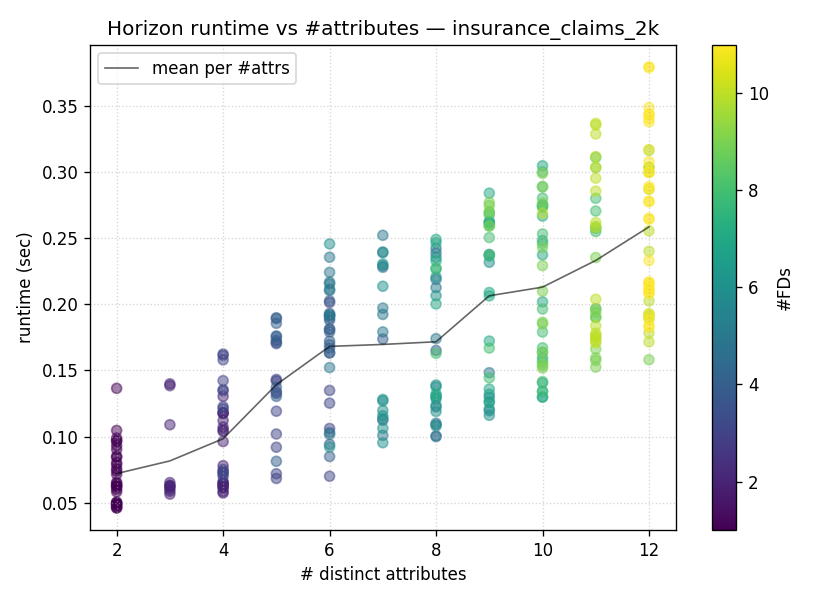

In [7]:
# Runtime vs #attributes (the chosen x-axis). Each kept round is a scatter point;
# the line connects the mean total per distinct attribute count. Saved to EXP_DIR
# and shown inline as a PNG (the Agg backend won't render figures directly).
from IPython.display import Image

agg = (
    stats.group_by("n_attrs")
    .agg(pl.col("total_secs").mean().alias("mean_total"))
    .sort("n_attrs")
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(stats["n_attrs"], stats["total_secs"], c=stats["n_fds"], cmap="viridis", alpha=0.5)
ax.plot(agg["n_attrs"], agg["mean_total"], "k-", lw=1, alpha=0.6, label="mean per #attrs")
sm = plt.cm.ScalarMappable(
    cmap="viridis", norm=plt.Normalize(stats["n_fds"].min(), stats["n_fds"].max())
)
fig.colorbar(sm, ax=ax, label="#FDs")
ax.set_xlabel("# distinct attributes")
ax.set_ylabel("runtime (sec)")
ax.set_title(f"Horizon runtime vs #attributes — {DATABASE}")
ax.grid(True, ls=":", alpha=0.5)
ax.legend()
fig.tight_layout()

plot_path = EXP_DIR / "runtime_vs_attrs.png"
fig.savefig(plot_path, dpi=120)
plt.close(fig)
Image(str(plot_path))